In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("house_price_dataset_1_lakh_with_nulls.csv")
df

,property_area_sqft,bedrooms,bathrooms,floors,year_built,renovation_status,lot_size_sqft,distance_city_center_km,neighborhood_quality,crime_rate_index,...,construction_quality,energy_efficiency,water_supply_score,electricity_supply_score,internet_score,green_space_index,flood_risk_index,noise_pollution_level,property_age,house_price
0,3674,4,3,2,1983,1,5631.0,11.89,1.3,69.5,...,8.8,6.5,3.4,7.3,5.6,9.9,9.5,2.4,42,1.806542e+07
1,1360,2,2,1,2006,0,3272.0,5.02,6.3,61.7,...,7.3,3.3,5.6,2.7,6.6,5.2,9.3,4.2,19,9.839487e+06
2,1794,4,2,1,1988,1,3472.0,19.92,1.1,59.5,...,6.3,3.5,5.0,6.9,NaN,6.5,1.0,6.4,37,7.775089e+06
3,1630,2,4,3,1979,0,1699.0,25.54,7.0,68.1,...,8.5,5.1,8.9,1.3,4.7,6.1,4.8,6.8,46,7.654648e+06
4,1595,3,2,1,1972,0,3662.0,13.41,9.5,1.9,...,7.6,1.6,4.4,7.0,5.1,8.4,3.8,2.4,53,1.038060e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1260,5,3,3,1988,1,NaN,29.17,6.9,92.2,...,7.6,4.7,6.1,9.9,4.3,9.3,4.7,7.2,37,7.798233e+06
99996,1622,3,4,3,2016,1,5186.0,11.65,9.6,55.0,...,8.4,9.7,3.1,4.0,7.0,1.6,5.6,4.1,9,1.202463e+07
99997,3257,1,2,2,2000,0,1616.0,9.99,5.8,44.6,...,8.1,5.8,5.1,3.0,8.7,4.7,7.6,8.6,25,1.808469e+07
99998,3374,3,2,2,2017,0,3410.0,3.75,4.0,85.2,...,9.3,4.1,4.5,5.9,7.7,1.3,7.9,7.7,8,1.900305e+07


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   property_area_sqft        100000 non-null  int64  
 1   bedrooms                  100000 non-null  int64  
 2   bathrooms                 100000 non-null  int64  
 3   floors                    100000 non-null  int64  
 4   year_built                100000 non-null  int64  
 5   renovation_status         100000 non-null  int64  
 6   lot_size_sqft             95000 non-null   float64
 7   distance_city_center_km   95000 non-null   float64
 8   neighborhood_quality      100000 non-null  float64
 9   crime_rate_index          100000 non-null  float64
 10  school_rating             95000 non-null   float64
 11  hospital_distance_km      95000 non-null   float64
 12  shopping_distance_km      100000 non-null  float64
 13  public_transport_score    100000 non-null  fl

,property_area_sqft,bedrooms,bathrooms,floors,year_built,renovation_status,lot_size_sqft,distance_city_center_km,neighborhood_quality,crime_rate_index,...,construction_quality,energy_efficiency,water_supply_score,electricity_supply_score,internet_score,green_space_index,flood_risk_index,noise_pollution_level,property_age,house_price
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,95000.000000,95000.000000,100000.000000,100000.000000,...,95000.000000,95000.000000,100000.000000,100000.000000,95000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2249.54639,2.999470,2.497390,2.001530,1996.507830,0.500980,3408.854526,15.274379,5.504676,50.457837,...,5.495960,5.486962,5.500049,5.489868,5.501043,5.495056,5.487975,5.504176,28.492170,1.239517e+07
std,1010.69636,1.415327,1.116963,0.818177,15.576799,0.500002,1500.796142,8.495334,2.602513,28.551116,...,2.591325,2.596364,2.598421,2.598326,2.597031,2.600320,2.597161,2.595652,15.576799,5.218312e+06
min,500.00000,1.000000,1.000000,1.000000,1970.000000,0.000000,800.000000,0.500000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.677959e+05
25%,1374.00000,2.000000,2.000000,1.000000,1983.000000,0.000000,2116.000000,7.960000,3.200000,25.700000,...,3.300000,3.200000,3.300000,3.300000,3.300000,3.200000,3.200000,3.300000,15.000000,8.024390e+06
50%,2250.00000,3.000000,2.000000,2.000000,1997.000000,1.000000,3411.000000,15.260000,5.500000,50.500000,...,5.500000,5.500000,5.500000,5.500000,5.500000,5.500000,5.500000,5.500000,28.000000,1.238141e+07
75%,3124.00000,4.000000,3.000000,3.000000,2010.000000,1.000000,4719.000000,22.620000,7.800000,75.100000,...,7.700000,7.700000,7.700000,7.700000,7.800000,7.800000,7.700000,7.700000,42.000000,1.676066e+07
max,3999.00000,5.000000,4.000000,3.000000,2023.000000,1.000000,5999.000000,30.000000,10.000000,100.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,55.000000,2.484709e+07


In [5]:
df.isnull().sum()

property_area_sqft             0
bedrooms                       0
bathrooms                      0
floors                         0
year_built                     0
renovation_status              0
lot_size_sqft               5000
distance_city_center_km     5000
neighborhood_quality           0
crime_rate_index               0
school_rating               5000
hospital_distance_km        5000
shopping_distance_km           0
public_transport_score         0
parking_available              0
property_type                  0
construction_quality        5000
energy_efficiency           5000
water_supply_score             0
electricity_supply_score       0
internet_score              5000
green_space_index              0
flood_risk_index               0
noise_pollution_level          0
property_age                   0
house_price                    0
dtype: int64

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

In [7]:
df.isnull().sum()

property_area_sqft          0
bedrooms                    0
bathrooms                   0
floors                      0
year_built                  0
renovation_status           0
lot_size_sqft               0
distance_city_center_km     0
neighborhood_quality        0
crime_rate_index            0
school_rating               0
hospital_distance_km        0
shopping_distance_km        0
public_transport_score      0
parking_available           0
property_type               0
construction_quality        0
energy_efficiency           0
water_supply_score          0
electricity_supply_score    0
internet_score              0
green_space_index           0
flood_risk_index            0
noise_pollution_level       0
property_age                0
house_price                 0
dtype: int64

In [8]:
X = df.drop("house_price", axis=1)
y = df["house_price"]

In [9]:
X
y

0        1.806542e+07
1        9.839487e+06
2        7.775089e+06
3        7.654648e+06
4        1.038060e+07
             ...     
99995    7.798233e+06
99996    1.202463e+07
99997    1.808469e+07
99998    1.900305e+07
99999    3.407399e+06
Name: house_price, Length: 100000, dtype: float64

In [10]:
null_counts = df.isnull().sum()
print(null_counts)

property_area_sqft          0
bedrooms                    0
bathrooms                   0
floors                      0
year_built                  0
renovation_status           0
lot_size_sqft               0
distance_city_center_km     0
neighborhood_quality        0
crime_rate_index            0
school_rating               0
hospital_distance_km        0
shopping_distance_km        0
public_transport_score      0
parking_available           0
property_type               0
construction_quality        0
energy_efficiency           0
water_supply_score          0
electricity_supply_score    0
internet_score              0
green_space_index           0
flood_risk_index            0
noise_pollution_level       0
property_age                0
house_price                 0
dtype: int64


In [11]:
df = pd.get_dummies(df, drop_first=True)
df

,property_area_sqft,bedrooms,bathrooms,floors,year_built,renovation_status,lot_size_sqft,distance_city_center_km,neighborhood_quality,crime_rate_index,...,water_supply_score,electricity_supply_score,internet_score,green_space_index,flood_risk_index,noise_pollution_level,property_age,house_price,property_type_Independent House,property_type_Villa
0,3674,4,3,2,1983,1,5631.000000,11.89,1.3,69.5,...,3.4,7.3,5.600000,9.9,9.5,2.4,42,1.806542e+07,False,False
1,1360,2,2,1,2006,0,3272.000000,5.02,6.3,61.7,...,5.6,2.7,6.600000,5.2,9.3,4.2,19,9.839487e+06,True,False
2,1794,4,2,1,1988,1,3472.000000,19.92,1.1,59.5,...,5.0,6.9,5.501043,6.5,1.0,6.4,37,7.775089e+06,False,True
3,1630,2,4,3,1979,0,1699.000000,25.54,7.0,68.1,...,8.9,1.3,4.700000,6.1,4.8,6.8,46,7.654648e+06,True,False
4,1595,3,2,1,1972,0,3662.000000,13.41,9.5,1.9,...,4.4,7.0,5.100000,8.4,3.8,2.4,53,1.038060e+07,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1260,5,3,3,1988,1,3408.854526,29.17,6.9,92.2,...,6.1,9.9,4.300000,9.3,4.7,7.2,37,7.798233e+06,False,False
99996,1622,3,4,3,2016,1,5186.000000,11.65,9.6,55.0,...,3.1,4.0,7.000000,1.6,5.6,4.1,9,1.202463e+07,True,False
99997,3257,1,2,2,2000,0,1616.000000,9.99,5.8,44.6,...,5.1,3.0,8.700000,4.7,7.6,8.6,25,1.808469e+07,False,True
99998,3374,3,2,2,2017,0,3410.000000,3.75,4.0,85.2,...,4.5,5.9,7.700000,1.3,7.9,7.7,8,1.900305e+07,False,False


In [36]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [35]:
print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numerical columns: ['property_area_sqft', 'bedrooms', 'bathrooms', 'floors', 'year_built', 'renovation_status', 'lot_size_sqft', 'distance_city_center_km', 'neighborhood_quality', 'crime_rate_index', 'school_rating', 'hospital_distance_km', 'shopping_distance_km', 'public_transport_score', 'parking_available', 'construction_quality', 'energy_efficiency', 'water_supply_score', 'electricity_supply_score', 'internet_score', 'green_space_index', 'flood_risk_index', 'noise_pollution_level', 'property_age', 'house_price']
Categorical columns: []


In [14]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [15]:
scaler = StandardScaler()
X = df.drop('house_price', axis=1)
y = df['house_price']

X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled

array([[ 1.40938544e+00,  7.06928642e-01,  4.49981468e-01, ...,
         8.67180580e-01, -7.05542882e-01, -7.06051686e-01],
       [-8.80136580e-01, -7.06179695e-01, -4.45308056e-01, ...,
        -6.09381780e-01,  1.41734829e+00, -7.06051686e-01],
       [-4.50727524e-01,  7.06928642e-01, -4.45308056e-01, ...,
         5.46188763e-01, -7.05542882e-01,  1.41632691e+00],
       ...,
       [ 9.96796553e-01, -1.41273386e+00, -4.45308056e-01, ...,
        -2.24191599e-01, -7.05542882e-01,  1.41632691e+00],
       [ 1.11255890e+00,  3.74473709e-04, -4.45308056e-01, ...,
        -1.31556378e+00, -7.05542882e-01, -7.06051686e-01],
       [-1.52622901e+00,  7.06928642e-01,  4.49981468e-01, ...,
        -6.09381780e-01,  1.41734829e+00, -7.06051686e-01]],
      shape=(100000, 26))

In [38]:
std_dev = y.std()
noise = np.random.normal(0, std_dev * 0.3, size=len(y))
y_noisy = y + noise
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_noisy, test_size=0.2, random_state=42)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
y_pred_lr

array([15379634.05142549, 19147875.600386  , 18402337.88339324, ...,
       16943274.56044358, 10128866.18065589,  3748993.0272647 ],
      shape=(20000,))

In [21]:
rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=8,             
    min_samples_split=10,    
    min_samples_leaf=5,      
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [23]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [24]:
print("Linear Regression:")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest:")
evaluate(y_test, y_pred_rf)

Linear Regression:
MAE: 1345661.2231712637
MSE: 2822255067952.322
RMSE: 1679956.8649082398
R2 Score: 0.9048360070932411

Random Forest:
MAE: 1391040.6441312379
MSE: 3009238154210.6074
RMSE: 1734715.5830886536
R2 Score: 0.8985310996111269


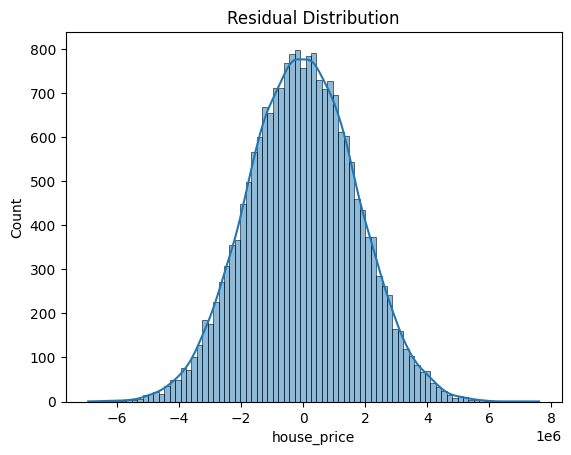

In [25]:
residuals = y_test - y_pred_rf

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

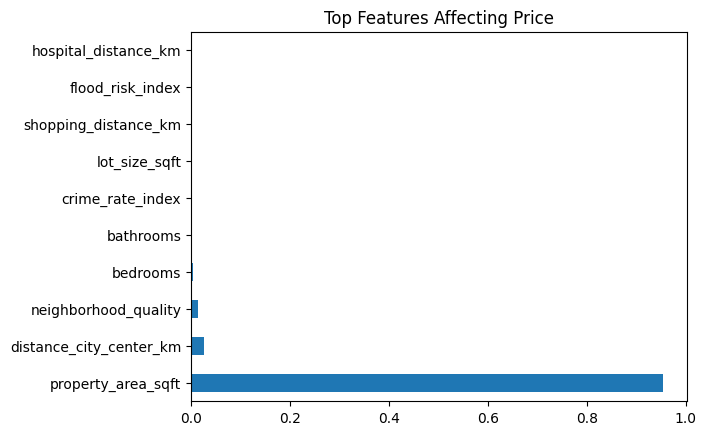

In [26]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Price")
plt.show()

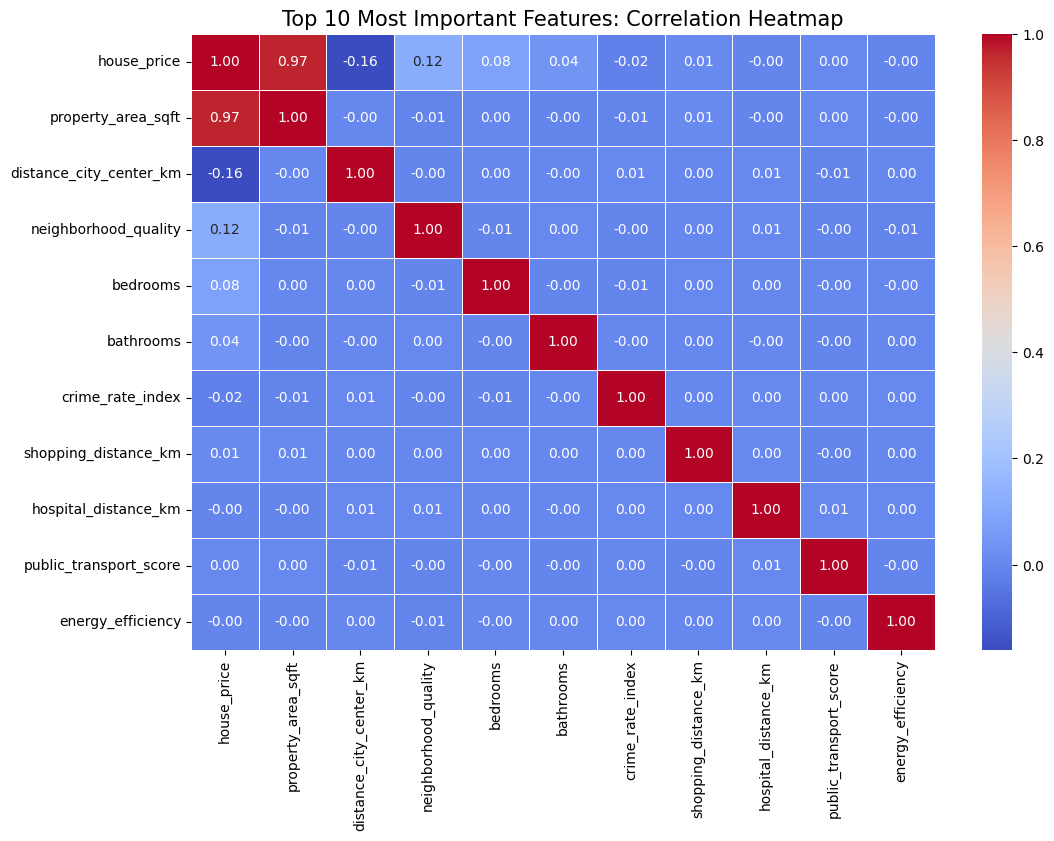

In [33]:
top_10_features = df.corr()['house_price'].abs().sort_values(ascending=False).head(11).index
top_corr_matrix = df[top_10_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(top_corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5)
plt.title('Top 10 Most Important Features: Correlation Heatmap', fontsize=15)
plt.show()

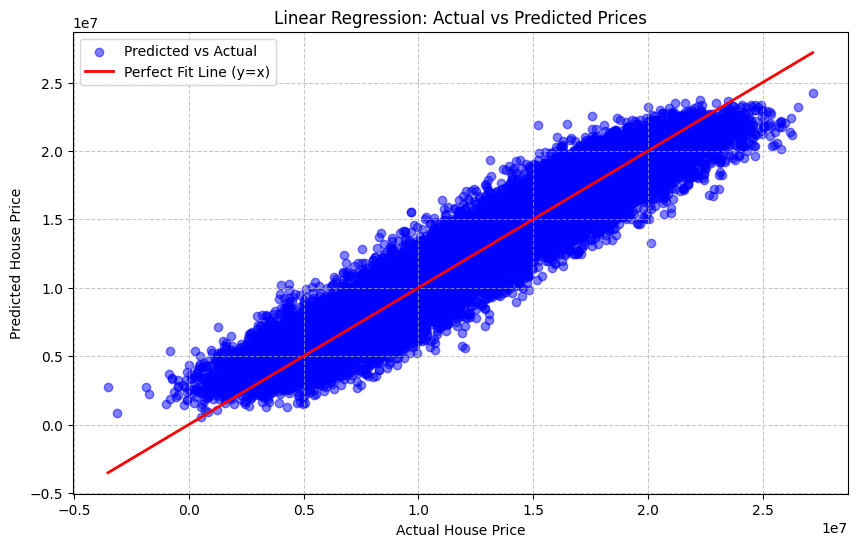

In [32]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue', label='Predicted vs Actual')
max_val = max(max(y_test), max(y_pred_lr))
min_val = min(min(y_test), min(y_pred_lr))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Perfect Fit Line (y=x)')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [39]:
def predict_house_price():
    print("--- Enter Property Details for Price Prediction ---")
    try:
        area = float(input("Enter Property Area (sqft): "))
        bedrooms = int(input("Enter Number of Bedrooms: "))
        bathrooms = int(input("Enter Number of Bathrooms: "))
        distance = float(input("Enter Distance from City Center (km): "))
        neighborhood = float(input("Enter Neighborhood Quality (1-10): "))
        input_data = {col: df[col].mean() for col in X.columns}
        input_data['property_area_sqft'] = area
        input_data['bedrooms'] = bedrooms
        input_data['bathrooms'] = bathrooms
        input_data['distance_city_center_km'] = distance
        input_data['neighborhood_quality'] = neighborhood
        input_df = pd.DataFrame([input_data])
        input_scaled = scaler.transform(input_df)
        prediction_lr = lr.predict(input_scaled)
        print("\n--- Prediction Results ---")
        print(f"Linear Regression Predicted Price: ₹{prediction_lr[0]:,.2f}")
    except ValueError:
        print("Invalid input! Please enter numerical values.")
predict_house_price()

--- Enter Property Details for Price Prediction ---


Enter Property Area (sqft):  300
Enter Number of Bedrooms:  3
Enter Number of Bathrooms:  3
Enter Distance from City Center (km):  8
Enter Neighborhood Quality (1-10):  7



--- Prediction Results ---
Linear Regression Predicted Price: ₹3,853,300.03
